In [1]:
!nvidia-smi | head -20

Wed May 20 19:22:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Upload your zip and extract it
from google.colab import files
import os, zipfile

uploaded = files.upload()                          # opens a file picker
zip_name = list(uploaded.keys())[0]
print(f'uploaded: {zip_name}')

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/')

PROJECT_ROOT = '/content/nalapro_colab'             # matches the folder inside the zip
os.makedirs(f'{PROJECT_ROOT}/data',    exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/models',  exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/outputs', exist_ok=True)
print('project root:', PROJECT_ROOT)
%cd {PROJECT_ROOT}

Saving nalapro_colab.zip to nalapro_colab.zip
uploaded: nalapro_colab.zip
project root: /content/nalapro_colab
/content/nalapro_colab


In [3]:
!pip install -q scikit-learn matplotlib numpy

In [4]:
import os, json, pickle, random
import numpy as np
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DATA_DIR = f'{PROJECT_ROOT}/data'

In [5]:
remove = ('headers', 'footers', 'quotes')
train_raw = fetch_20newsgroups(subset='train', remove=remove, random_state=RANDOM_SEED)
test_raw  = fetch_20newsgroups(subset='test',  remove=remove, random_state=RANDOM_SEED)

target_names = list(train_raw.target_names)
NUM_CLASSES  = len(target_names)
print(f'Train docs: {len(train_raw.data):,}')
print(f'Test docs:  {len(test_raw.data):,}')
print(f'Classes:    {NUM_CLASSES}')

Train docs: 11,314
Test docs:  7,532
Classes:    20


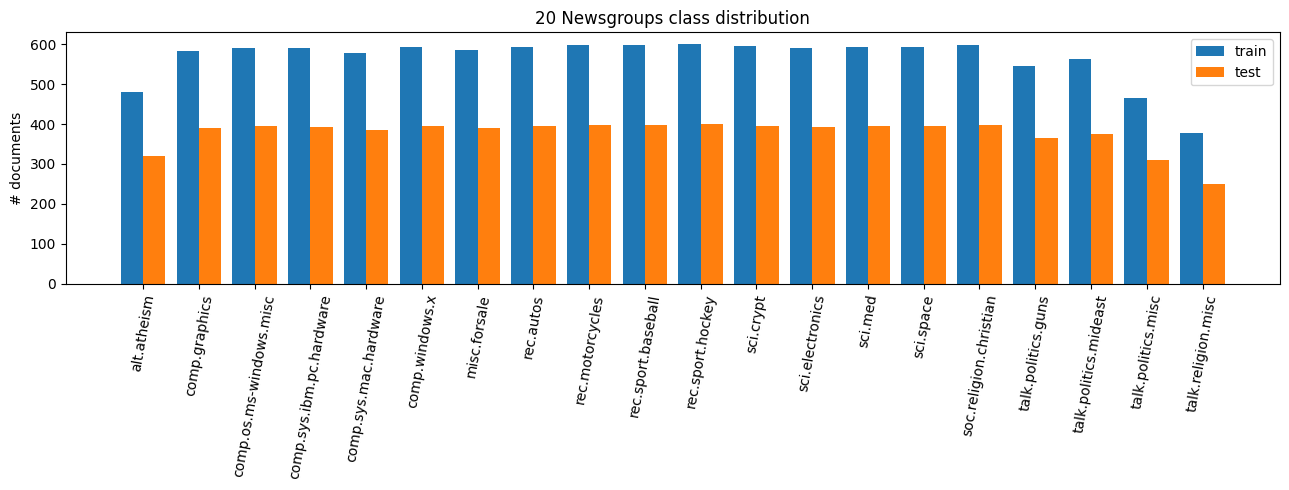

In [6]:
import matplotlib.pyplot as plt

counts_train = Counter(train_raw.target)
counts_test  = Counter(test_raw.target)
x = np.arange(NUM_CLASSES); w = 0.4
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, [counts_train[i] for i in range(NUM_CLASSES)], w, label='train')
ax.bar(x + w/2, [counts_test[i]  for i in range(NUM_CLASSES)], w, label='test')
ax.set_xticks(x); ax.set_xticklabels(target_names, rotation=80)
ax.set_ylabel('# documents'); ax.set_title('20 Newsgroups class distribution')
ax.legend(); plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/00_class_distribution.png', dpi=120)
plt.show()

In [7]:
X_train_full = list(train_raw.data); y_train_full = train_raw.target.tolist()
X_test       = list(test_raw.data);  y_test       = test_raw.target.tolist()

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.10,
    stratify=y_train_full, random_state=RANDOM_SEED)
print(f'train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}')

train: 10182  val: 1132  test: 7532


In [8]:
# Full dataset (Task 1 — simple NN)
full = {'train_texts': X_train, 'train_labels': y_train,
        'val_texts': X_val, 'val_labels': y_val,
        'test_texts': X_test, 'test_labels': y_test,
        'target_names': target_names}
with open(f'{DATA_DIR}/full_dataset.pkl', 'wb') as f:
    pickle.dump(full, f)
print('saved full_dataset.pkl')

saved full_dataset.pkl


In [9]:
# BERT dataset — class-balanced training (cap at 600/class), full val and test
PER_CLASS_TRAIN_CAP = 600
rng = np.random.RandomState(RANDOM_SEED)
by_class = {}
for t, y in zip(X_train, y_train):
    by_class.setdefault(y, []).append(t)

X_train_cap, y_train_cap = [], []
for y in sorted(by_class):
    texts = by_class[y]
    idx   = rng.permutation(len(texts))[:PER_CLASS_TRAIN_CAP]
    X_train_cap.extend(texts[i] for i in idx)
    y_train_cap.extend([y] * len(idx))
p = rng.permutation(len(X_train_cap))
X_train_cap = [X_train_cap[i] for i in p]
y_train_cap = [y_train_cap[i] for i in p]

bert = {'train_texts': X_train_cap, 'train_labels': y_train_cap,
        'val_texts': X_val, 'val_labels': y_val,
        'test_texts': X_test, 'test_labels': y_test,
        'mlm_corpus': X_train_full,
        'target_names': target_names,
        'per_class_cap': PER_CLASS_TRAIN_CAP}
with open(f'{DATA_DIR}/bert_dataset.pkl', 'wb') as f:
    pickle.dump(bert, f)
print(f'bert train: {len(X_train_cap)}  val: {len(X_val)}  test: {len(X_test)}')
print(f'mlm corpus: {len(X_train_full)}')
print('train class counts:', dict(sorted(Counter(y_train_cap).items())))

bert train: 10182  val: 1132  test: 7532
mlm corpus: 11314
train class counts: {0: 432, 1: 526, 2: 532, 3: 531, 4: 520, 5: 534, 6: 526, 7: 535, 8: 538, 9: 537, 10: 540, 11: 535, 12: 532, 13: 535, 14: 534, 15: 539, 16: 491, 17: 508, 18: 418, 19: 339}


In [10]:
# Tiny balanced eval set for Llama-3 (5 docs/class)
PER_CLASS_TINY = 5
by_class_test = {}
for t, y in zip(X_test, y_test):
    by_class_test.setdefault(y, []).append(t)
tiny_x, tiny_y = [], []
for y in sorted(by_class_test):
    texts = by_class_test[y]
    idx = rng.permutation(len(texts))[:PER_CLASS_TINY]
    tiny_x.extend(texts[i] for i in idx)
    tiny_y.extend([y] * len(idx))
tiny = {'test_texts': tiny_x, 'test_labels': tiny_y,
        'few_shot_pool_texts': X_train_cap,
        'few_shot_pool_labels': y_train_cap,
        'target_names': target_names}
with open(f'{DATA_DIR}/tiny_eval.pkl', 'wb') as f:
    pickle.dump(tiny, f)
print(f'tiny eval: {len(tiny_x)} docs ({PER_CLASS_TINY}/class * {NUM_CLASSES})')

tiny eval: 100 docs (5/class * 20)


**Task 1: Simple NN + word2vec / TF-IDF**

In [11]:
!pip install -q gensim wandb nltk
import nltk
for pkg in ['stopwords', 'punkt', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.2 MB/s eta 0:00:00


In [12]:
import wandb
wandb.login()  # reads WANDB_API_KEY from environment (see .env.example)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: raghav9raghav (raghav9raghav-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
import pickle, re, time, random, json, os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
from gensim.models import Word2Vec
from scipy import sparse
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


In [14]:
with open(f'{PROJECT_ROOT}/data/full_dataset.pkl', 'rb') as f:
    data = pickle.load(f)
train_texts = data['train_texts']; y_train = np.array(data['train_labels'])
val_texts   = data['val_texts'];   y_val   = np.array(data['val_labels'])
test_texts  = data['test_texts'];  y_test  = np.array(data['test_labels'])
target_names = data['target_names']
NUM_CLASSES  = len(target_names)
print(f'train={len(train_texts)}  val={len(val_texts)}  test={len(test_texts)}  classes={NUM_CLASSES}')

train=10182  val=1132  test=7532  classes=20


In [15]:
#preprocessing
STOP = set(stopwords.words('english'))
URL_RE   = re.compile(r'https?://\S+|www\.\S+')
EMAIL_RE = re.compile(r'\S+@\S+')
NUM_RE   = re.compile(r'\d+')
NONWORD  = re.compile(r"[^a-z\s']")

def preprocess(text):
    t = text.lower()
    t = URL_RE.sub(' ', t); t = EMAIL_RE.sub(' ', t)
    t = NUM_RE.sub(' ', t); t = NONWORD.sub(' ', t)
    toks = word_tokenize(t)
    return [w for w in toks if len(w) >= 3 and w not in STOP]

t0 = time.time()
train_tokens = [preprocess(t) for t in train_texts]
val_tokens   = [preprocess(t) for t in val_texts]
test_tokens  = [preprocess(t) for t in test_texts]
print(f'tokenised in {time.time()-t0:.1f}s')

tokenised in 12.8s


In [16]:
#word2vec
EMB_DIM, WINDOW, MIN_COUNT = 100, 5, 5
WORKERS = max(1, os.cpu_count() - 1)

print('training word2vec — 1 epoch ...')
t0 = time.time()
w2v_1 = Word2Vec(train_tokens, vector_size=EMB_DIM, window=WINDOW,
                 min_count=MIN_COUNT, workers=WORKERS, epochs=1, seed=SEED, sg=1)
print(f'  done in {time.time()-t0:.1f}s  vocab={len(w2v_1.wv)}')

print('training word2vec — 30 epochs ...')
t0 = time.time()
w2v_N = Word2Vec(train_tokens, vector_size=EMB_DIM, window=WINDOW,
                 min_count=MIN_COUNT, workers=WORKERS, epochs=30, seed=SEED, sg=1)
print(f'  done in {time.time()-t0:.1f}s  vocab={len(w2v_N.wv)}')

training word2vec — 1 epoch ...
  done in 8.3s  vocab=17296
training word2vec — 30 epochs ...
  done in 255.6s  vocab=17296


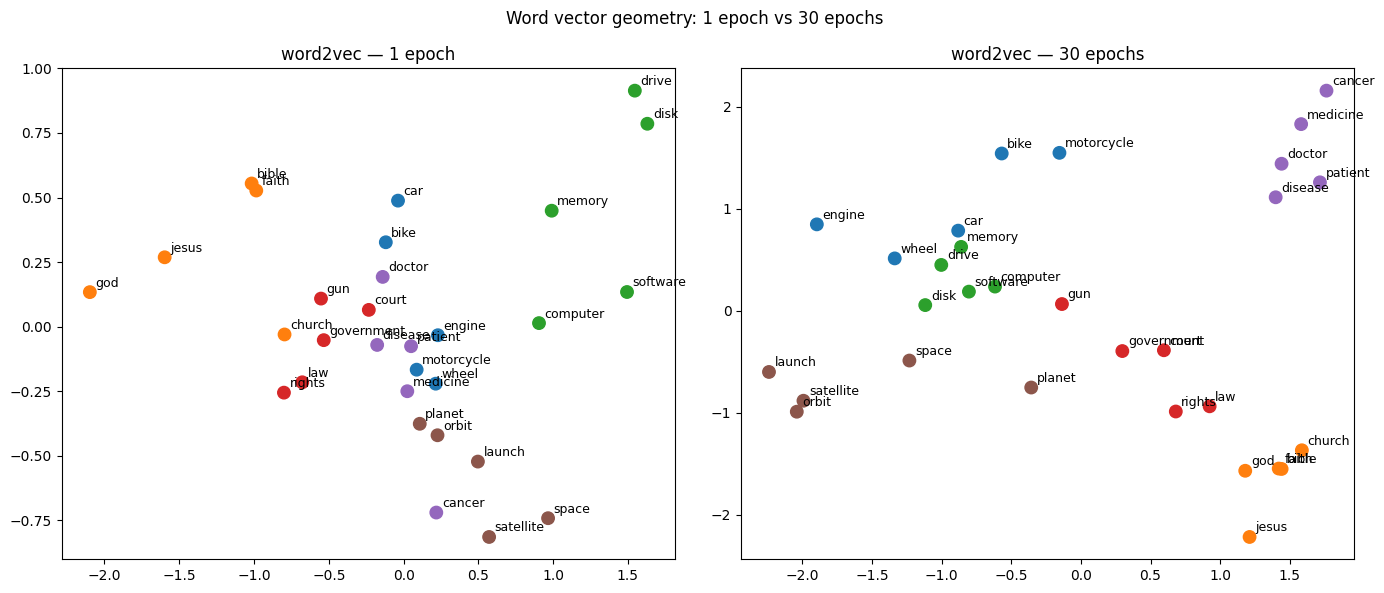

In [17]:
probe_words = [
    'car', 'engine', 'wheel', 'motorcycle', 'bike',
    'god', 'jesus', 'church', 'faith', 'bible',
    'computer', 'software', 'memory', 'disk', 'drive',
    'government', 'gun', 'law', 'rights', 'court',
    'doctor', 'patient', 'disease', 'medicine', 'cancer',
    'space', 'orbit', 'planet', 'launch', 'satellite']
common = [w for w in probe_words if w in w2v_1.wv and w in w2v_N.wv]
V1 = np.array([w2v_1.wv[w] for w in common])
VN = np.array([w2v_N.wv[w] for w in common])
p1 = PCA(n_components=2, random_state=SEED).fit_transform(V1)
pN = PCA(n_components=2, random_state=SEED).fit_transform(VN)

topics = {**dict.fromkeys(['car','engine','wheel','motorcycle','bike'], 0),
          **dict.fromkeys(['god','jesus','church','faith','bible'], 1),
          **dict.fromkeys(['computer','software','memory','disk','drive'], 2),
          **dict.fromkeys(['government','gun','law','rights','court'], 3),
          **dict.fromkeys(['doctor','patient','disease','medicine','cancer'], 4),
          **dict.fromkeys(['space','orbit','planet','launch','satellite'], 5)}
cmap = plt.get_cmap('tab10')
colors = [cmap(topics.get(w, 9)) for w in common]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, P, title in [(axes[0], p1, 'word2vec — 1 epoch'),
                     (axes[1], pN, 'word2vec — 30 epochs')]:
    ax.scatter(P[:, 0], P[:, 1], c=colors, s=80)
    for (x, y), w in zip(P, common):
        ax.annotate(w, (x, y), fontsize=9, xytext=(4, 4), textcoords='offset points')
    ax.set_title(title)
plt.suptitle('Word vector geometry: 1 epoch vs 30 epochs')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/01_w2v_epochs.png', dpi=120)
plt.show()

In [18]:
#Simple NN + training utility
def doc_vectors(token_lists, model):
    out = np.zeros((len(token_lists), model.vector_size), dtype=np.float32)
    for i, toks in enumerate(token_lists):
        vecs = [model.wv[w] for w in toks if w in model.wv]
        if vecs:
            out[i] = np.mean(vecs, axis=0)
    return out

class SimpleNN(nn.Module):
    def __init__(self, in_dim, hidden, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, n_classes)
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

def to_dense_t(X):
    if sparse.issparse(X):
        return torch.from_numpy(X.toarray().astype(np.float32))
    return torch.from_numpy(X.astype(np.float32))

def run_experiment(name, Xtr, ytr, Xval, yval, Xte, yte, *,
                   hidden=128, epochs=15, lr=1e-3, bs=64):
    torch.manual_seed(SEED)
    in_dim = Xtr.shape[1]
    model  = SimpleNN(in_dim, hidden, NUM_CLASSES).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    crit   = nn.CrossEntropyLoss()

    Xval_t = to_dense_t(Xval).to(DEVICE); Xte_t = to_dense_t(Xte).to(DEVICE)
    yval_a = np.asarray(yval); yte_a = np.asarray(yte)

    run = wandb.init(project='nalapro-20news', name=f'task1-{name}',
                     config=dict(model='SimpleNN', input=name, hidden=hidden,
                                 epochs=epochs, lr=lr, batch=bs,
                                 input_dim=in_dim, classes=NUM_CLASSES,
                                 device=str(DEVICE)),
                     reinit=True)

    history = []
    n = Xtr.shape[0]
    for ep in range(epochs):
        model.train()
        idx = np.random.permutation(n); running = 0.0; nseen = 0
        for s in range(0, n, bs):
            ii = idx[s:s+bs]
            if sparse.issparse(Xtr):
                xb = torch.from_numpy(Xtr[ii].toarray().astype(np.float32)).to(DEVICE)
            else:
                xb = torch.from_numpy(Xtr[ii].astype(np.float32)).to(DEVICE)
            yb = torch.from_numpy(np.asarray(ytr)[ii]).to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            running += loss.item() * xb.size(0); nseen += xb.size(0)
        model.eval()
        with torch.no_grad():
            val_pred = model(Xval_t).argmax(dim=1).cpu().numpy()
        val_acc = accuracy_score(yval_a, val_pred)
        val_f1  = f1_score(yval_a, val_pred, average='macro')
        train_loss = running / nseen
        history.append({'epoch': ep+1, 'train_loss': train_loss,
                        'val_acc': val_acc, 'val_f1': val_f1})
        wandb.log({'train_loss': train_loss, 'val_acc': val_acc,
                   'val_f1': val_f1, 'epoch': ep+1})
    # final test eval
    model.eval()
    with torch.no_grad():
        test_pred = model(Xte_t).argmax(dim=1).cpu().numpy()
    test_acc = accuracy_score(yte_a, test_pred)
    test_f1  = f1_score(yte_a, test_pred, average='macro')
    wandb.log({'test_acc': test_acc, 'test_f1': test_f1})
    wandb.finish()
    print(f'  {name:25s}  val_acc={history[-1]["val_acc"]:.4f}  '
          f'test_acc={test_acc:.4f}  test_f1={test_f1:.4f}')
    return {'name': name, 'history': history,
            'test_acc': float(test_acc), 'test_f1': float(test_f1)}

In [19]:
#Run all four experiments
results = {}

Xtr = doc_vectors(train_tokens, w2v_1)
Xv  = doc_vectors(val_tokens,   w2v_1)
Xt  = doc_vectors(test_tokens,  w2v_1)
results['w2v_1ep'] = run_experiment('w2v-1epoch', Xtr, y_train, Xv, y_val, Xt, y_test)

Xtr = doc_vectors(train_tokens, w2v_N)
Xv  = doc_vectors(val_tokens,   w2v_N)
Xt  = doc_vectors(test_tokens,  w2v_N)
results['w2v_30ep'] = run_experiment('w2v-30epoch', Xtr, y_train, Xv, y_val, Xt, y_test)

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁
val_acc,▁▃▃▄▅▆▆▆▇▇█▇▇▇█
val_f1,▁▄▃▅▅▆▆▆▇▇█▇█▇█
epoch,15
test_acc,0.28147
test_f1,0.24442
train_loss,2.17415
val_acc,0.28445


  w2v-1epoch                 val_acc=0.2845  test_acc=0.2815  test_f1=0.2444


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▅▇▇▇▇▇█▇█████
val_f1,▁▄▆▇▇▇▇▇▇▇██▇▇█
epoch,15
test_acc,0.63688
test_f1,0.6217
train_loss,0.96749
val_acc,0.68905


  w2v-30epoch                val_acc=0.6890  test_acc=0.6369  test_f1=0.6217


In [20]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,1),
                        sublinear_tf=True, min_df=2, max_df=0.9,
                        stop_words='english')
Xtr = tfidf.fit_transform(train_texts).astype(np.float32)
Xv  = tfidf.transform(val_texts).astype(np.float32)
Xt  = tfidf.transform(test_texts).astype(np.float32)
print('TF-IDF shape:', Xtr.shape)
results['tfidf'] = run_experiment('tfidf', Xtr, y_train, Xv, y_val, Xt, y_test, bs=128)

TF-IDF shape: (10182, 10000)


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▆▄▃▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▅▇▇█████████▇▇
val_f1,▁▅▇▇███████████
epoch,15
test_acc,0.67897
test_f1,0.67023
train_loss,0.12397
val_acc,0.7606


  tfidf                      val_acc=0.7606  test_acc=0.6790  test_f1=0.6702


In [21]:
vocab, idf = tfidf.vocabulary_, tfidf.idf_
def w2v_tfidf_doc_vectors(token_lists, model):
    out = np.zeros((len(token_lists), model.vector_size), dtype=np.float32)
    for i, toks in enumerate(token_lists):
        vecs, wts = [], []
        for w in toks:
            if w in model.wv and w in vocab:
                vecs.append(model.wv[w]); wts.append(idf[vocab[w]])
        if vecs:
            V = np.asarray(vecs); W = np.asarray(wts, dtype=np.float32)
            out[i] = (V * W[:, None]).sum(axis=0) / W.sum()
    return out

Xtr = w2v_tfidf_doc_vectors(train_tokens, w2v_N)
Xv  = w2v_tfidf_doc_vectors(val_tokens,   w2v_N)
Xt  = w2v_tfidf_doc_vectors(test_tokens,  w2v_N)
results['w2v_tfidf'] = run_experiment('w2v-tfidf-weighted', Xtr, y_train, Xv, y_val, Xt, y_test)

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_f1,▁
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▆▆▆▇▇██▇██████
val_f1,▁▆▆▆▇▇██▇██████
epoch,15
test_acc,0.63197
test_f1,0.61618
train_loss,0.97575
val_acc,0.66873


  w2v-tfidf-weighted         val_acc=0.6687  test_acc=0.6320  test_f1=0.6162


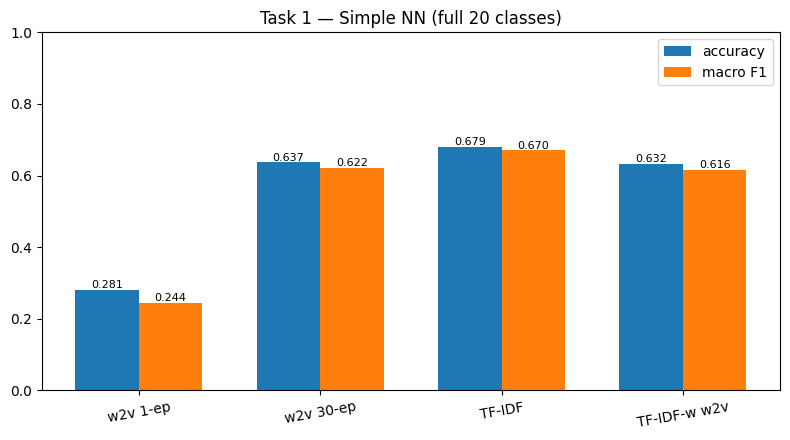

saved.


In [22]:
#Comparison plot
labels = ['w2v 1-ep', 'w2v 30-ep', 'TF-IDF', 'TF-IDF-w w2v']
keys   = ['w2v_1ep', 'w2v_30ep', 'tfidf', 'w2v_tfidf']
accs   = [results[k]['test_acc'] for k in keys]
f1s    = [results[k]['test_f1']  for k in keys]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, accs, w, label='accuracy')
ax.bar(x + w/2, f1s,  w, label='macro F1')
for i, v in enumerate(accs): ax.text(i - w/2, v + .005, f'{v:.3f}', ha='center', fontsize=8)
for i, v in enumerate(f1s):  ax.text(i + w/2, v + .005, f'{v:.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10)
ax.set_ylim(0, 1); ax.legend()
ax.set_title('Task 1 — Simple NN (full 20 classes)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/01_task1_comparison.png', dpi=120)
plt.show()

with open(f'{PROJECT_ROOT}/outputs/01_task1_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('saved.')

**Task 2: BERT-base fine-tuning**

In [23]:
!pip install -q transformers accelerate wandb scikit-learn

In [24]:
import os, pickle, time, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
USE_FP16 = (DEVICE.type == 'cuda')   # mixed precision on GPU only

device: cuda
GPU: Tesla T4
memory: 15.6 GB


In [25]:
with open(f'{PROJECT_ROOT}/data/bert_dataset.pkl', 'rb') as f:
    data = pickle.load(f)
train_texts, y_train = data['train_texts'], data['train_labels']
val_texts,   y_val   = data['val_texts'],   data['val_labels']
test_texts,  y_test  = data['test_texts'],  data['test_labels']
target_names = data['target_names']
NUM_CLASSES  = len(target_names)
print(f'train={len(train_texts)}  val={len(val_texts)}  test={len(test_texts)}  classes={NUM_CLASSES}')

train=10182  val=1132  test=7532  classes=20


In [26]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(texts, padding='max_length', truncation=True,
                     max_length=MAX_LEN, return_tensors='pt')

t0 = time.time()
train_enc = tokenize(train_texts)
val_enc   = tokenize(val_texts)
test_enc  = tokenize(test_texts)
print(f'tokenised in {time.time()-t0:.1f}s')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenised in 44.0s


In [27]:
class EncodedDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return self.labels.size(0)
    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i],
                'labels':         self.labels[i]}

train_ds = EncodedDataset(train_enc, y_train)
val_ds   = EncodedDataset(val_enc,   y_val)
test_ds  = EncodedDataset(test_enc,  y_test)

In [28]:
#Model + optimiser
BATCH_SIZE    = 32          # GPU can afford bigger batches
EPOCHS        = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable params: {trainable/1e6:.1f}M (full fine-tune)')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE * 2,
                          num_workers=2, pin_memory=(DEVICE.type=='cuda'))

no_decay = ['bias', 'LayerNorm.weight']
grouped = [
    {'params': [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     'weight_decay': WEIGHT_DECAY},
    {'params': [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]
optimizer = torch.optim.AdamW(grouped, lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, int(total_steps * WARMUP_RATIO), total_steps)

scaler = torch.cuda.amp.GradScaler() if USE_FP16 else None
print(f'total optimiser steps: {total_steps}, fp16: {USE_FP16}')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 109.5M (full fine-tune)
total optimiser steps: 957, fp16: True


/tmp/ipykernel_8094/3324945283.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_FP16 else None


In [29]:
#Training loop with mixed precision
wandb.init(project='nalapro-20news', name='task2-bert-base-20class-gpu',
           config=dict(model=MODEL_NAME, max_len=MAX_LEN, batch=BATCH_SIZE,
                       epochs=EPOCHS, lr=LEARNING_RATE,
                       weight_decay=WEIGHT_DECAY, warmup=WARMUP_RATIO,
                       classes=NUM_CLASSES, train_size=len(train_ds),
                       fp16=USE_FP16, device=str(DEVICE)))

def evaluate(model, loader):
    model.eval()
    P, Y = [], []
    with torch.no_grad():
        for b in loader:
            b = {k: v.to(DEVICE, non_blocking=True) for k, v in b.items()}
            if USE_FP16:
                with torch.cuda.amp.autocast():
                    o = model(input_ids=b['input_ids'], attention_mask=b['attention_mask'])
            else:
                o = model(input_ids=b['input_ids'], attention_mask=b['attention_mask'])
            P.extend(o.logits.argmax(dim=-1).cpu().numpy())
            Y.extend(b['labels'].cpu().numpy())
    return np.array(Y), np.array(P)

history = {'train_loss': [], 'val_acc': [], 'val_f1': [], 'epoch_time': []}
for epoch in range(EPOCHS):
    t_ep = time.time()
    model.train()
    running = 0.0; nsteps = 0
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        optimizer.zero_grad()
        if USE_FP16:
            with torch.cuda.amp.autocast():
                out = model(**batch); loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            out = model(**batch); loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()
        running += loss.item(); nsteps += 1
        if (step + 1) % 50 == 0:
            print(f'  ep{epoch+1} step {step+1}/{len(train_loader)}  '
                  f'loss={running/nsteps:.4f}  elapsed={time.time()-t_ep:.0f}s')
            wandb.log({'running_loss': running/nsteps,
                       'global_step': epoch*len(train_loader)+step})
    y, p = evaluate(model, val_loader)
    val_acc = accuracy_score(y, p); val_f1 = f1_score(y, p, average='macro')
    dt = time.time() - t_ep
    history['train_loss'].append(running / nsteps)
    history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
    history['epoch_time'].append(dt)
    wandb.log({'train_loss': running/nsteps, 'val_acc': val_acc,
               'val_f1': val_f1, 'epoch_time': dt, 'epoch': epoch + 1})
    print(f'EPOCH {epoch+1}: train_loss={running/nsteps:.4f}  '
          f'val_acc={val_acc:.4f}  val_f1={val_f1:.4f}  time={dt/60:.1f}min')


/tmp/ipykernel_8094/3710864913.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  ep1 step 50/319  loss=3.0286  elapsed=11s
  ep1 step 100/319  loss=2.9216  elapsed=21s
  ep1 step 150/319  loss=2.7077  elapsed=31s
  ep1 step 200/319  loss=2.4837  elapsed=40s
  ep1 step 250/319  loss=2.3014  elapsed=51s
  ep1 step 300/319  loss=2.1539  elapsed=61s


/tmp/ipykernel_8094/3710864913.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


EPOCH 1: train_loss=2.1073  val_acc=0.6625  val_f1=0.6245  time=1.1min


/tmp/ipykernel_8094/3710864913.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

EPOCH 2: train_loss=1.0588  val_acc=0.7235  val_f1=0.7008  time=1.2min


/tmp/ipykernel_8094/3710864913.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  ep3 step 50/319  loss=0.8021  elapsed=11s
  ep3 step 100/319  loss=0.8360  elapsed=22s
  ep3 step 150/319  loss=0.8207  elapsed=33s
  ep3 step 200/319  loss=0.8075  elapsed=44s
  ep3 step 250/319  loss=0.8068  elapsed=54s
  ep3 step 300/319  loss=0.8040  elapsed=65s


/tmp/ipykernel_8094/3710864913.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


EPOCH 3: train_loss=0.8021  val_acc=0.7341  val_f1=0.7122  time=1.2min


/tmp/ipykernel_8094/3710864913.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


TEST acc=0.6880  f1_macro=0.6638
                          precision    recall  f1-score   support

             alt.atheism     0.4317    0.4357    0.4337       319
           comp.graphics     0.6472    0.6555    0.6513       389
 comp.os.ms-windows.misc     0.6460    0.6624    0.6541       394
comp.sys.ibm.pc.hardware     0.6132    0.6148    0.6140       392
   comp.sys.mac.hardware     0.7197    0.6468    0.6813       385
          comp.windows.x     0.7969    0.7747    0.7856       395
            misc.forsale     0.8144    0.8103    0.8123       390
               rec.autos     0.5352    0.7879    0.6374       396
         rec.motorcycles     0.7534    0.6985    0.7249       398
      rec.sport.baseball     0.8895    0.8312    0.8594       397
        rec.sport.hockey     0.8807    0.8697    0.8752       399
               sci.crypt     0.7644    0.6717    0.7151       396
         sci.electronics     0.6417    0.5878    0.6135       393
                 sci.med     0.8333    0.8

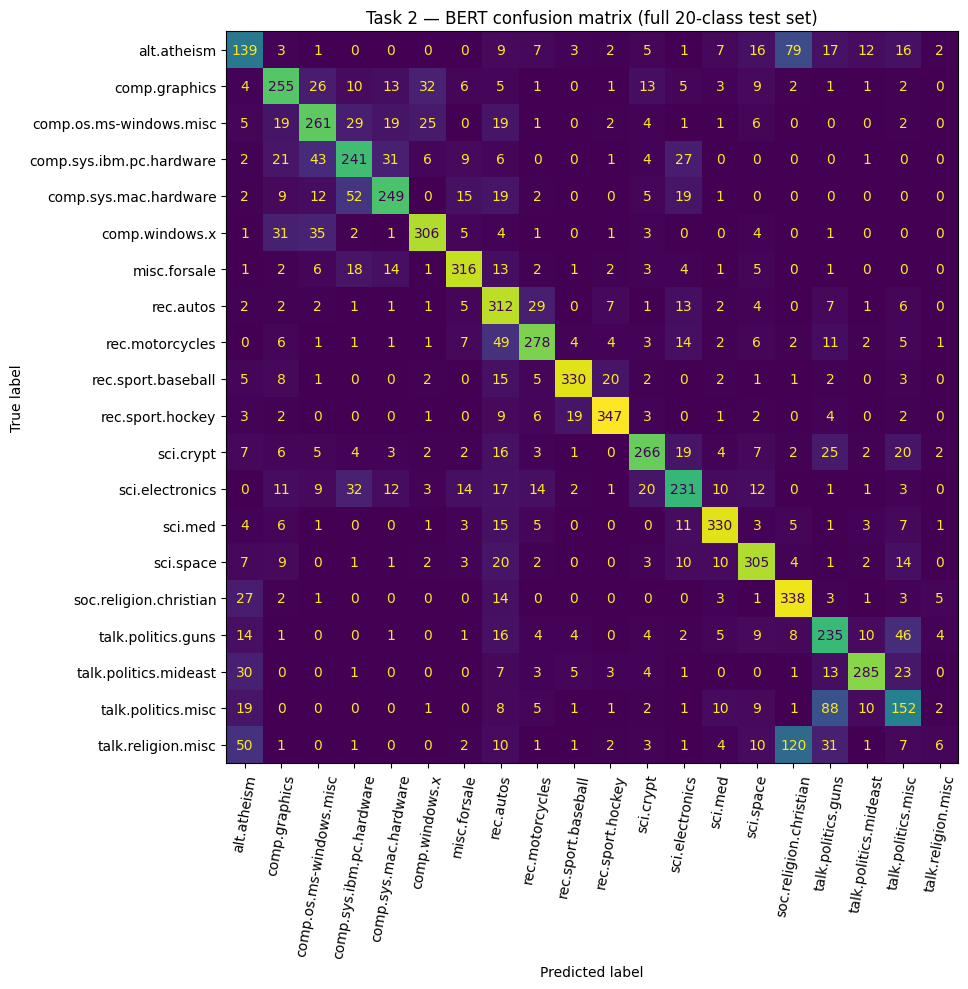

epoch,▁▅█
epoch_time,▁█▆
global_step,▁▁▂▂▃▃▄▄▄▅▅▅▆▆▇▇██
running_loss,██▇▆▆▅▂▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_f1,▁
train_loss,█▂▁
val_acc,▁▇█
val_f1,▁▇█
epoch,3
epoch_time,70.96687


In [30]:
#Final test-set evaluation + confusion matrix
y_te, p_te = evaluate(model, test_loader)
test_acc = accuracy_score(y_te, p_te)
test_f1  = f1_score(y_te, p_te, average='macro')
print(f'TEST acc={test_acc:.4f}  f1_macro={test_f1:.4f}')
print(classification_report(y_te, p_te, target_names=target_names, digits=4))

fig, ax = plt.subplots(figsize=(11, 10))
ConfusionMatrixDisplay.from_predictions(y_te, p_te, display_labels=target_names,
                                       xticks_rotation=80, ax=ax, colorbar=False,
                                       values_format='d')
ax.set_title('Task 2 — BERT confusion matrix (full 20-class test set)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/02_bert_confusion.png', dpi=110)
plt.show()

wandb.log({'test_acc': test_acc, 'test_f1': test_f1,
           'confusion_matrix': wandb.Image(f'{PROJECT_ROOT}/outputs/02_bert_confusion.png')})
wandb.finish()


In [31]:
results = {'model': MODEL_NAME, 'max_len': MAX_LEN, 'batch_size': BATCH_SIZE,
           'epochs': EPOCHS, 'lr': LEARNING_RATE, 'fp16': USE_FP16,
           'history': history,
           'test_acc': float(test_acc), 'test_f1_macro': float(test_f1),
           'target_names': target_names}
with open(f'{PROJECT_ROOT}/outputs/02_bert_results.json', 'w') as f:
    json.dump(results, f, indent=2)
model.save_pretrained(f'{PROJECT_ROOT}/models/bert_finetuned')
tokenizer.save_pretrained(f'{PROJECT_ROOT}/models/bert_finetuned')
print('saved to Drive')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to Drive


**TASK 2 V2**

**Task 3: Domain-adaptive MLM, then classify**

In [32]:
!pip install -q transformers accelerate wandb scikit-learn

In [33]:
import os, pickle, time, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForMaskedLM,
                          AutoModelForSequenceClassification,
                          DataCollatorForLanguageModeling,
                          get_linear_schedule_with_warmup)
from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_FP16 = (DEVICE.type == 'cuda')
print('device:', DEVICE, ' fp16:', USE_FP16)

device: cuda  fp16: True


In [34]:
with open(f'{PROJECT_ROOT}/data/bert_dataset.pkl', 'rb') as f:
    data = pickle.load(f)
mlm_corpus = data['mlm_corpus']
train_texts, y_train = data['train_texts'], data['train_labels']
val_texts,   y_val   = data['val_texts'],   data['val_labels']
test_texts,  y_test  = data['test_texts'],  data['test_labels']
target_names = data['target_names']
NUM_CLASSES  = len(target_names)
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'mlm corpus: {len(mlm_corpus)}  cls train: {len(train_texts)}  test: {len(test_texts)}')

mlm corpus: 11314  cls train: 10182  test: 7532


In [35]:
#MLM
class MLMDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=128):
        self.enc = tokenizer(texts, padding='max_length', truncation=True,
                             max_length=max_len, return_tensors='pt')
    def __len__(self): return self.enc['input_ids'].size(0)
    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i]}

mlm_ds = MLMDataset(mlm_corpus, tokenizer, MAX_LEN)
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).to(DEVICE)

MLM_EPOCHS = 1; MLM_BS = 32; MLM_LR = 5e-5
wandb.init(project='nalapro-20news', name='task3-mlm-stage-gpu',
           config=dict(model=MODEL_NAME, max_len=MAX_LEN, batch=MLM_BS,
                       epochs=MLM_EPOCHS, lr=MLM_LR,
                       corpus_size=len(mlm_corpus), mask_prob=0.15,
                       fp16=USE_FP16))

loader = DataLoader(mlm_ds, batch_size=MLM_BS, shuffle=True, collate_fn=collator,
                    num_workers=2, pin_memory=USE_FP16)
opt = torch.optim.AdamW(mlm_model.parameters(), lr=MLM_LR)
total_steps = len(loader) * MLM_EPOCHS
sched = get_linear_schedule_with_warmup(opt, int(total_steps * 0.1), total_steps)
scaler = torch.cuda.amp.GradScaler() if USE_FP16 else None

mlm_history = []
for ep in range(MLM_EPOCHS):
    mlm_model.train(); running = 0.0; nsteps = 0; t0 = time.time()
    for step, batch in enumerate(loader):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        opt.zero_grad()
        if USE_FP16:
            with torch.cuda.amp.autocast():
                out = mlm_model(**batch); loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        else:
            out = mlm_model(**batch); loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mlm_model.parameters(), 1.0)
            opt.step()
        sched.step()
        running += loss.item(); nsteps += 1
        if (step + 1) % 50 == 0:
            print(f'  MLM ep{ep+1} step {step+1}/{len(loader)} loss={running/nsteps:.4f} elapsed={time.time()-t0:.0f}s')
            wandb.log({'mlm_running_loss': running/nsteps})
    mlm_history.append(running / nsteps)
    wandb.log({'mlm_loss': running/nsteps, 'mlm_epoch': ep+1,
               'mlm_epoch_time': time.time()-t0})
    print(f'MLM epoch {ep+1}: mean loss={running/nsteps:.4f} ({time.time()-t0:.0f}s)')

MLM_DIR = f'{PROJECT_ROOT}/models/bert_mlm_adapted'
mlm_model.save_pretrained(MLM_DIR); tokenizer.save_pretrained(MLM_DIR)
wandb.finish()
print('saved MLM-adapted BERT')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


/tmp/ipykernel_8094/1949563992.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_FP16 else None
/tmp/ipykernel_8094/1949563992.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  MLM ep1 step 50/354 loss=2.6627 elapsed=13s
  MLM ep1 step 100/354 loss=2.5658 elapsed=27s
  MLM ep1 step 150/354 loss=2.5276 elapsed=40s
  MLM ep1 step 200/354 loss=2.5079 elapsed=54s
  MLM ep1 step 250/354 loss=2.4908 elapsed=68s
  MLM ep1 step 300/354 loss=2.4711 elapsed=82s
  MLM ep1 step 350/354 loss=2.4589 elapsed=97s
MLM epoch 1: mean loss=2.4586 (98s)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

mlm_epoch,▁
mlm_epoch_time,▁
mlm_loss,▁
mlm_running_loss,█▅▃▃▂▁▁
mlm_epoch,1
mlm_epoch_time,97.64935
mlm_loss,2.45861
mlm_running_loss,2.45894


saved MLM-adapted BERT


In [36]:
#classification on the MLM-adapted model
class EncodedDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc = tokenizer(texts, padding='max_length', truncation=True,
                             max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return self.labels.size(0)
    def __getitem__(self, i):
        return {'input_ids':      self.enc['input_ids'][i],
                'attention_mask': self.enc['attention_mask'][i],
                'labels':         self.labels[i]}

train_ds = EncodedDataset(train_texts, y_train, tokenizer, MAX_LEN)
val_ds   = EncodedDataset(val_texts,   y_val,   tokenizer, MAX_LEN)
test_ds  = EncodedDataset(test_texts,  y_test,  tokenizer, MAX_LEN)

cls_model = AutoModelForSequenceClassification.from_pretrained(
    MLM_DIR, num_labels=NUM_CLASSES).to(DEVICE)

BATCH = 32; EPOCHS = 3; LR = 2e-5
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=USE_FP16)
val_loader   = DataLoader(val_ds,   batch_size=BATCH*2, num_workers=2, pin_memory=USE_FP16)
test_loader  = DataLoader(test_ds,  batch_size=BATCH*2, num_workers=2, pin_memory=USE_FP16)

no_decay = ['bias', 'LayerNorm.weight']
grouped = [
    {'params': [p for n, p in cls_model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in cls_model.named_parameters()
                if any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
opt = torch.optim.AdamW(grouped, lr=LR)
total_steps = len(train_loader) * EPOCHS
sched = get_linear_schedule_with_warmup(opt, int(total_steps * 0.1), total_steps)
scaler = torch.cuda.amp.GradScaler() if USE_FP16 else None

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /content/nalapro_colab/models/bert_mlm_adapted
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipy

In [37]:
wandb.init(project='nalapro-20news', name='task3-mlm-then-classify-gpu',
           config=dict(model=MODEL_NAME, max_len=MAX_LEN, batch=BATCH,
                       epochs=EPOCHS, lr=LR, mlm_pretrained=True,
                       mlm_corpus_size=len(mlm_corpus),
                       classes=NUM_CLASSES, fp16=USE_FP16))

def eval_cls(model, loader):
    model.eval()
    P, Y = [], []
    with torch.no_grad():
        for b in loader:
            b = {k: v.to(DEVICE, non_blocking=True) for k, v in b.items()}
            if USE_FP16:
                with torch.cuda.amp.autocast():
                    o = model(input_ids=b['input_ids'], attention_mask=b['attention_mask'])
            else:
                o = model(input_ids=b['input_ids'], attention_mask=b['attention_mask'])
            P.extend(o.logits.argmax(dim=-1).cpu().numpy())
            Y.extend(b['labels'].cpu().numpy())
    return np.array(Y), np.array(P)

history = {'train_loss': [], 'val_acc': [], 'val_f1': []}
for ep in range(EPOCHS):
    cls_model.train(); running = 0.0; nsteps = 0; t0 = time.time()
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        opt.zero_grad()
        if USE_FP16:
            with torch.cuda.amp.autocast():
                out = cls_model(**batch); loss = out.loss
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(cls_model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
        else:
            out = cls_model(**batch); loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cls_model.parameters(), 1.0)
            opt.step()
        sched.step()
        running += loss.item(); nsteps += 1
        if (step + 1) % 50 == 0:
            print(f'  cls ep{ep+1} step {step+1}/{len(train_loader)} loss={running/nsteps:.4f} elapsed={time.time()-t0:.0f}s')
    y, p = eval_cls(cls_model, val_loader)
    val_acc = accuracy_score(y, p); val_f1 = f1_score(y, p, average='macro')
    history['train_loss'].append(running/nsteps)
    history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
    wandb.log({'train_loss': running/nsteps, 'val_acc': val_acc,
               'val_f1': val_f1, 'epoch': ep+1, 'epoch_time': time.time()-t0})
    print(f'cls ep{ep+1}: loss={running/nsteps:.4f}  val_acc={val_acc:.4f}  '
          f'val_f1={val_f1:.4f}  ({time.time()-t0:.0f}s)')

/tmp/ipykernel_8094/1775776336.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  cls ep1 step 50/319 loss=2.9728 elapsed=11s
  cls ep1 step 100/319 loss=2.7589 elapsed=22s
  cls ep1 step 150/319 loss=2.4351 elapsed=33s
  cls ep1 step 200/319 loss=2.1905 elapsed=43s
  cls ep1 step 250/319 loss=2.0178 elapsed=54s
  cls ep1 step 300/319 loss=1.8882 elapsed=65s


/tmp/ipykernel_8094/1775776336.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


cls ep1: loss=1.8483  val_acc=0.6961  val_f1=0.6668  (71s)


/tmp/ipykernel_8094/1775776336.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

cls ep2: loss=0.9453  val_acc=0.7367  val_f1=0.7150  (70s)


/tmp/ipykernel_8094/1775776336.py:29: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  cls ep3 step 50/319 loss=0.7138 elapsed=11s
  cls ep3 step 100/319 loss=0.7000 elapsed=22s
  cls ep3 step 150/319 loss=0.7152 elapsed=33s
  cls ep3 step 200/319 loss=0.7234 elapsed=43s
  cls ep3 step 250/319 loss=0.7208 elapsed=54s
  cls ep3 step 300/319 loss=0.7290 elapsed=65s


/tmp/ipykernel_8094/1775776336.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


cls ep3: loss=0.7288  val_acc=0.7473  val_f1=0.7229  (74s)


In [38]:
#Final test evaluation + comparison plot
y_te, p_te = eval_cls(cls_model, test_loader)
test_acc = accuracy_score(y_te, p_te)
test_f1  = f1_score(y_te, p_te, average='macro')
print(f'TEST acc={test_acc:.4f}  f1_macro={test_f1:.4f}')
print(classification_report(y_te, p_te, target_names=target_names, digits=4))
wandb.log({'test_acc': test_acc, 'test_f1': test_f1})
wandb.finish()

results3 = {'mlm_loss_history': mlm_history, 'cls_history': history,
            'test_acc': float(test_acc), 'test_f1_macro': float(test_f1)}
with open(f'{PROJECT_ROOT}/outputs/03_task3_results.json', 'w') as f:
    json.dump(results3, f, indent=2)

/tmp/ipykernel_8094/1775776336.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


TEST acc=0.6932  f1_macro=0.6707
                          precision    recall  f1-score   support

             alt.atheism     0.4302    0.4828    0.4549       319
           comp.graphics     0.7040    0.6787    0.6911       389
 comp.os.ms-windows.misc     0.6527    0.6726    0.6625       394
comp.sys.ibm.pc.hardware     0.6102    0.6429    0.6261       392
   comp.sys.mac.hardware     0.7308    0.6909    0.7103       385
          comp.windows.x     0.8500    0.7316    0.7864       395
            misc.forsale     0.8470    0.8231    0.8349       390
               rec.autos     0.5312    0.7727    0.6296       396
         rec.motorcycles     0.7432    0.6834    0.7120       398
      rec.sport.baseball     0.9178    0.8161    0.8640       397
        rec.sport.hockey     0.8765    0.8897    0.8831       399
               sci.crypt     0.7563    0.6818    0.7171       396
         sci.electronics     0.6170    0.6107    0.6138       393
                 sci.med     0.8308    0.8

epoch,▁▅█
epoch_time,▃▁█
test_acc,▁
test_f1,▁
train_loss,█▂▁
val_acc,▁▇█
val_f1,▁▇█
epoch,3
epoch_time,73.82291
test_acc,0.69318
test_f1,0.67069


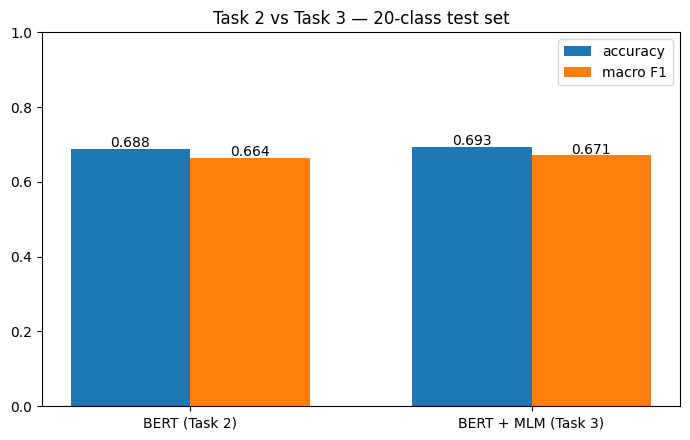

In [39]:
task2 = json.load(open(f'{PROJECT_ROOT}/outputs/02_bert_results.json'))
task3 = results3
names = ['BERT (Task 2)', 'BERT + MLM (Task 3)']
accs  = [task2['test_acc'],      task3['test_acc']]
f1s   = [task2['test_f1_macro'], task3['test_f1_macro']]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(names)); w = 0.35
ax.bar(x - w/2, accs, w, label='accuracy')
ax.bar(x + w/2, f1s,  w, label='macro F1')
for i, v in enumerate(accs): ax.text(i - w/2, v + .005, f'{v:.3f}', ha='center')
for i, v in enumerate(f1s):  ax.text(i + w/2, v + .005, f'{v:.3f}', ha='center')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1); ax.legend()
ax.set_title('Task 2 vs Task 3 — 20-class test set')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/03_task2_vs_task3.png', dpi=120)
plt.show()

**Task 4: Llama-3 zero-shot and few-shot**

In [40]:
!pip install -q transformers accelerate bitsandbytes wandb scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00


In [41]:
from huggingface_hub import login
login()

In [42]:
import os, pickle, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics import accuracy_score, f1_score, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0),
          f'memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

device: cuda
GPU: Tesla T4 memory: 15.6 GB


In [43]:
MODEL_GATED   = 'meta-llama/Llama-3.2-3B-Instruct'
MODEL_UNGATED = 'NousResearch/Meta-Llama-3.1-8B-Instruct'   # alt — also Llama-3 family

MODEL_NAME = MODEL_GATED
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16, device_map='auto')
    print(f'loaded {MODEL_NAME}')
except Exception as e:
    print(f'failed to load gated model: {e}')
    print(f'falling back to {MODEL_UNGATED}')
    MODEL_NAME = MODEL_UNGATED
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16, device_map='auto')
    print(f'loaded {MODEL_NAME}')

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model.eval()

failed to load gated model: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct.
403 Client Error. (Request ID: Root=1-6a0e11bb-42c2154103ceb81f5476a2af;05c79816-c1a3-4b12-b9cd-5b9f9b15100e)

Cannot access gated repo for url https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct/resolve/main/config.json.
Access to model meta-llama/Llama-3.2-3B-Instruct is restricted and you are not in the authorized list. Visit https://huggingface.co/meta-llama/Llama-3.2-3B-Instruct to ask for access.
falling back to NousResearch/Meta-Llama-3.1-8B-Instruct


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

loaded NousResearch/Meta-Llama-3.1-8B-Instruct


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
  

In [44]:
with open(f'{PROJECT_ROOT}/data/tiny_eval.pkl', 'rb') as f:
    tiny = pickle.load(f)
test_texts   = tiny['test_texts']
test_labels  = tiny['test_labels']
target_names = tiny['target_names']
label_names  = list(target_names)
NUM_CLASSES  = len(label_names)
y_true_names = [label_names[y] for y in test_labels]
pool_texts   = tiny['few_shot_pool_texts']
pool_labels  = tiny['few_shot_pool_labels']
print(f'eval: {len(test_texts)} docs across {NUM_CLASSES} classes')

eval: 100 docs across 20 classes


In [52]:
def truncate(text, max_words):
    return ' '.join(text.split()[:max_words])

def normalise_label(text, candidates):
    t = text.strip().lower()

    for c in candidates:
        if c.lower() in t:
            return c

    toks = set(t.replace('.', ' ').replace(',', ' ').split())

    best, score = candidates[0], -1

    for c in candidates:
        s = len(toks & set(c.lower().replace('.', ' ').split()))
        if s > score:
            best, score = c, s

    return best


SYSTEM_MSG = (
    'You are a strict text classifier. '
    'The user will give you a newsgroup post. '
    'Reply with EXACTLY ONE of the following category labels, '
    'copied verbatim, and nothing else:\n'
    + '\n'.join(label_names)
)


@torch.no_grad()
def llama_classify(text, examples=None, max_new_tokens=20):

    msgs = [
        {
            'role': 'system',
            'content': SYSTEM_MSG
        }
    ]

    if examples:
        for ex_text, ex_label in examples:

            msgs.append({
                'role': 'user',
                'content': f'Post:\n{truncate(ex_text, 60)}\n\nLabel:'
            })

            msgs.append({
                'role': 'assistant',
                'content': ex_label
            })

    msgs.append({
        'role': 'user',
        'content': f'Post:\n{truncate(text, 200)}\n\nLabel:'
    })

    # Create prompt text
    prompt = tokenizer.apply_chat_template(
        msgs,
        tokenize=False,
        add_generation_prompt=True
    )

    # Tokenize properly
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(DEVICE)

    # Generate
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode only generated tokens
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    raw = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    pred = normalise_label(raw, label_names)

    return pred, raw

In [ ]:
#Zero-shot
wandb.init(project='nalapro-20news', name='task4-llama3-zero-shot-gpu',
           config=dict(model=MODEL_NAME, eval_size=len(test_texts),
                       classes=NUM_CLASSES, mode='zero-shot'))

preds_zs, raw_zs = [], []
t0 = time.time()
for i, text in enumerate(test_texts):
    p, r = llama_classify(text, examples=None)
    preds_zs.append(p); raw_zs.append(r)
    if (i + 1) % 10 == 0:
        el = time.time() - t0
        eta = el / (i + 1) * (len(test_texts) - i - 1)
        print(f'  {i+1}/{len(test_texts)}  elapsed={el:.0f}s  eta={eta:.0f}s')
acc_zs = accuracy_score(y_true_names, preds_zs)
f1_zs  = f1_score(y_true_names, preds_zs, labels=label_names, average='macro', zero_division=0)
print(f'zero-shot:  acc={acc_zs:.4f}  macro_f1={f1_zs:.4f}')
wandb.log({'test_acc': acc_zs, 'test_f1': f1_zs, 'duration_s': time.time()-t0})
wandb.finish()

In [ ]:
#Few-shot
by_cls = {}
for t, y in zip(pool_texts, pool_labels):
    by_cls.setdefault(y, []).append(t)
few_shot_examples = [(by_cls[y][0], label_names[y]) for y in sorted(by_cls)]
print(f'{len(few_shot_examples)} demonstrations')

wandb.init(project='nalapro-20news', name='task4-llama3-few-shot-gpu',
           config=dict(model=MODEL_NAME, eval_size=len(test_texts),
                       classes=NUM_CLASSES, mode='few-shot', shots_per_class=1))

preds_fs, raw_fs = [], []
t0 = time.time()
for i, text in enumerate(test_texts):
    p, r = llama_classify(text, examples=few_shot_examples)
    preds_fs.append(p); raw_fs.append(r)
    if (i + 1) % 5 == 0:
        el = time.time() - t0
        eta = el / (i + 1) * (len(test_texts) - i - 1)
        print(f'  {i+1}/{len(test_texts)}  elapsed={el:.0f}s  eta={eta:.0f}s')
acc_fs = accuracy_score(y_true_names, preds_fs)
f1_fs  = f1_score(y_true_names, preds_fs, labels=label_names, average='macro', zero_division=0)
print(f'few-shot:  acc={acc_fs:.4f}  macro_f1={f1_fs:.4f}')
wandb.log({'test_acc': acc_fs, 'test_f1': f1_fs, 'duration_s': time.time()-t0})
wandb.finish()

In [ ]:
#Fair comparison
from transformers import AutoModelForSequenceClassification
BERT_DIR = f'{PROJECT_ROOT}/models/bert_finetuned'
if os.path.exists(BERT_DIR):
    tok = AutoTokenizer.from_pretrained(BERT_DIR)
    m   = AutoModelForSequenceClassification.from_pretrained(BERT_DIR).to(DEVICE)
    m.eval()
    enc = tok(test_texts, padding='max_length', truncation=True, max_length=128, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = m(**enc).logits
    preds_bert = [label_names[i] for i in logits.argmax(dim=-1).cpu().numpy()]
    acc_bert = accuracy_score(y_true_names, preds_bert)
    f1_bert  = f1_score(y_true_names, preds_bert, labels=label_names, average='macro', zero_division=0)
    print(f'BERT on same 100 docs: acc={acc_bert:.4f}  f1={f1_bert:.4f}')
    # free VRAM
    del m; torch.cuda.empty_cache()
else:
    acc_bert = f1_bert = None
    print('Run Notebook 02 first.')

In [ ]:
labels = ['Llama-3 zero-shot', 'Llama-3 few-shot']
accs   = [acc_zs, acc_fs]
f1s    = [f1_zs,  f1_fs]
if acc_bert is not None:
    labels.append('BERT fine-tuned'); accs.append(acc_bert); f1s.append(f1_bert)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(labels)); w = 0.35
ax.bar(x - w/2, accs, w, label='accuracy')
ax.bar(x + w/2, f1s,  w, label='macro F1')
for i, v in enumerate(accs): ax.text(i - w/2, v + .005, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(f1s):  ax.text(i + w/2, v + .005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1); ax.legend()
ax.set_title('Task 4 — Llama-3 vs fine-tuned BERT on same 100-doc set (20 classes)')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/outputs/04_llama_vs_bert.png', dpi=120)
plt.show()

results4 = {
    'model': MODEL_NAME,
    'zero_shot': {'acc': float(acc_zs), 'f1': float(f1_zs)},
    'few_shot':  {'acc': float(acc_fs), 'f1': float(f1_fs)},
    'bert_on_same_set': ({'acc': float(acc_bert), 'f1': float(f1_bert)}
                         if acc_bert is not None else None),
    'eval_size': len(test_texts), 'classes': NUM_CLASSES,
}
with open(f'{PROJECT_ROOT}/outputs/04_llama_results.json', 'w') as f:
    json.dump(results4, f, indent=2)
print('saved.')